#DECISION TREE

In [2]:
# Data prepartion
# Loading libraries and functions
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pandas import read_csv, get_dummies, Series, DataFrame, Categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from plotly import figure_factory as ff
from sklearn import linear_model
from sklearn.model_selection import GridSearchCV

In [3]:
data=read_csv('/content/CVD_cleaned.csv')

In [ ]:
data.columns

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History',
       'Alcohol_Consumption', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'FriedPotato_Consumption'],
      dtype='object')

In [4]:
sample_data=data.sample(n=30000,random_state=42)

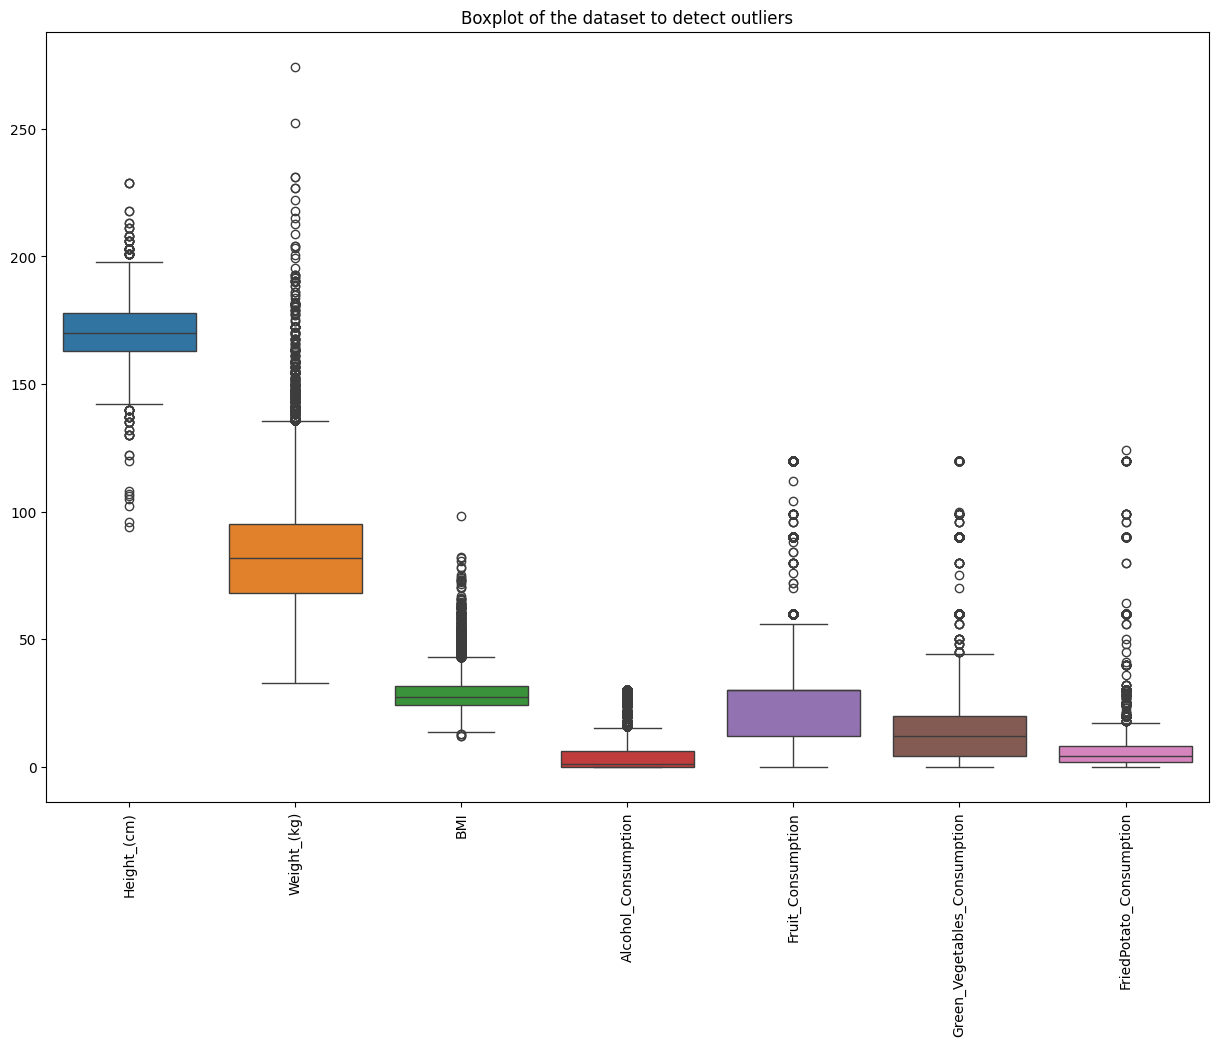

In [5]:
plt.figure(figsize=(15,10))
sns.boxplot(data=sample_data)
plt.title('Boxplot of the dataset to detect outliers')
plt.xticks(rotation=90)
plt.show()


In [6]:
data=sample_data

In [ ]:
data.describe()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,170.579000,83.407960,28.573977,5.039833,29.916900,15.101433,6.218267
std,10.636453,21.126082,6.440203,8.133186,24.927209,14.932949,8.679079
min,94.000000,32.660000,12.160000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.270000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.750000,6.000000,30.000000,20.000000,8.000000
max,229.000000,274.420000,98.440000,30.000000,120.000000,120.000000,124.000000


In [ ]:
data.shape

(30000, 19)

In [ ]:
data.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
302051,Very Good,Within the past year,Yes,No,No,No,No,No,Yes,Male,60-64,178.0,86.18,27.26,No,12.0,30.0,16.0,8.0
59950,Very Good,Within the past year,No,No,No,No,No,No,Yes,Female,70-74,165.0,79.38,29.12,No,0.0,60.0,60.0,12.0
203639,Good,Within the past year,No,No,No,No,No,No,Yes,Female,60-64,168.0,72.57,25.82,Yes,6.0,0.0,20.0,0.0
78768,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,183.0,93.89,28.07,Yes,0.0,60.0,8.0,2.0
216156,Fair,Within the past year,Yes,No,Yes,No,Yes,"No, pre-diabetes or borderline diabetes",Yes,Female,55-59,160.0,54.43,21.26,Yes,0.0,20.0,6.0,15.0


In [ ]:
binary_coloums=[col for col in data.columns if data[col].nunique()==2]
print(binary_coloums)

['Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Arthritis', 'Sex', 'Smoking_History']


In [7]:
data['Exercise'] = data['Exercise'].map({'Yes':1, 'No':0})
data['Heart_Disease'] = data['Heart_Disease'].map({'Yes':1, 'No':0})
data['Skin_Cancer'] = data['Skin_Cancer'].map({'Yes':1,'No':0})
data['Other_Cancer'] = data['Other_Cancer'].map({'Yes':1,'No':0})
data['Depression'] = data['Depression'].map({'Yes':1,'No':0})
data['Arthritis'] = data['Arthritis'].map({'Yes':1,'No':0})
data['Sex'] = data['Sex'].map({'Male':1,'Female':0})
data['Smoking_History'] = data['Smoking_History'].map({'Yes':1,'No':0})

In [8]:
data2 = get_dummies(data, columns=['General_Health', 'Checkup', 'Age_Category','Diabetes'], dtype=int)

In [9]:
# Seggreagating the data into X and Y features i.e., independent and dependent features
X=data2.drop('Heart_Disease',axis=1) # Independent features
Y=data2['Heart_Disease'] # Dependent features

In [ ]:
X.head()

,Exercise,Skin_Cancer,Other_Cancer,Depression,Arthritis,Sex,Height_(cm),Weight_(kg),BMI,Smoking_History,...,Age_Category_55-59,Age_Category_60-64,Age_Category_65-69,Age_Category_70-74,Age_Category_75-79,Age_Category_80+,Diabetes_No,"Diabetes_No, pre-diabetes or borderline diabetes",Diabetes_Yes,"Diabetes_Yes, but female told only during pregnancy"
302051,1,0,0,0,1,1,178.0,86.18,27.26,0,...,0,1,0,0,0,0,1,0,0,0
59950,0,0,0,0,1,0,165.0,79.38,29.12,0,...,0,0,0,1,0,0,1,0,0,0
203639,0,0,0,0,1,0,168.0,72.57,25.82,1,...,0,1,0,0,0,0,1,0,0,0
78768,1,0,0,0,0,1,183.0,93.89,28.07,1,...,0,0,0,0,0,0,1,0,0,0
216156,1,1,0,1,1,0,160.0,54.43,21.26,1,...,1,0,0,0,0,0,0,1,0,0


In [10]:
# Normalization/ Standardisation of the dataset
X_scaled=StandardScaler().fit_transform(X)

In [11]:
# Splitting the dataset into training and testing
X_train,X_test,Y_train,Y_test= train_test_split(X_scaled,Y, test_size=0.3,random_state=1)

In [12]:
# Balancing the dataset using SMOTE technique
X_train, Y_train=SMOTE(random_state=1).fit_resample(X_train,Y_train) # Balancing the class labels

# Decision Trees

In [13]:
from sklearn import tree

In [14]:
dec_tree= tree.DecisionTreeClassifier(criterion='entropy',max_depth=5) #Decision Tree Classifier Building

In [15]:
dec_tree.fit(X_train,Y_train) # Fitting decision tree classifier to the training set

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [16]:
Y_pred=dec_tree.predict(X_test) # Predicted Y value on the test dataset

In [17]:
from sklearn import metrics
Accuracy= metrics.accuracy_score(Y_test,Y_pred)
Recall= metrics.recall_score(Y_test,Y_pred)
Precision= metrics.precision_score(Y_test,Y_pred)
print('Accuracy:', Accuracy)
print('Recall:', Recall)
print('Precision:', Precision)

Accuracy: 0.7883333333333333
Recall: 0.5370629370629371
Precision: 0.1961184882533197


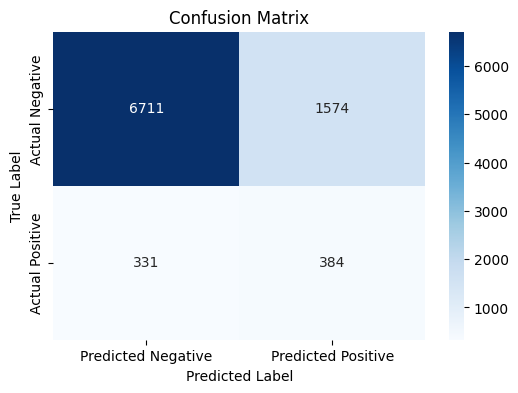

In [18]:
conf_mat= metrics.confusion_matrix(Y_test,Y_pred) # Confusion matrix
conf_mat

plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Negative", "Predicted Positive"], yticklabels=["Actual Negative", "Actual Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

dec_tree2= tree.DecisionTreeClassifier(criterion='entropy')

depth={'max_depth': [2,4,5,6,8,9,10,12,25,28,30,36]}

grid_search=GridSearchCV(estimator=dec_tree2,param_grid=depth,scoring='precision',cv=5)

grid_search.fit(X_train,Y_train)
best_depth= grid_search.best_params_
print(best_depth)


{'max_depth': 28}


In [ ]:
 # Refitting the model with the optimal/best max_depth parameter selected based on the precision
dec_tree_best_depth= tree.DecisionTreeClassifier(criterion='entropy',max_depth=8)
dec_tree_best_depth.fit(X_train,Y_train)
Y_pred=dec_tree_best_depth.predict(X_test)

In [ ]:
from sklearn import metrics
Accuracy= metrics.accuracy_score(Y_test,Y_pred)
Recall= metrics.recall_score(Y_test,Y_pred)
Precision= metrics.precision_score(Y_test,Y_pred)
print('Accuracy:', Accuracy)
print('Recall:', Recall)
print('Precision:', Precision)

Accuracy: 0.8382222222222222
Recall: 0.4307692307692308
Precision: 0.22697126013264554


In [ ]:
# Selecting the optimal features
dec_tree_best_depth_impt_feat= tree.DecisionTreeClassifier(criterion='entropy',max_depth=6)
dec_tree_best_depth_impt_feat.fit(X_train,Y_train)
Y_pred_impt_feat=dec_tree_best_depth_impt_feat.predict(X_test)
imp_features=Series(dec_tree_best_depth_impt_feat.feature_importances_,index=list(X)).sort_values(ascending=False)
print(imp_features)

Arthritis                                              0.426660
Smoking_History                                        0.316260
Sex                                                    0.081910
Diabetes_Yes                                           0.034803
General_Health_Excellent                               0.032988
General_Health_Very Good                               0.019666
General_Health_Fair                                    0.017608
Age_Category_80+                                       0.015189
Checkup_Within the past year                           0.014802
Age_Category_75-79                                     0.013994
General_Health_Good                                    0.010002
Fruit_Consumption                                      0.003435
Depression                                             0.002849
Age_Category_70-74                                     0.002753
Exercise                                               0.002122
Other_Cancer                            

#RANDOM FOREST

In [ ]:
# Data prepartion
# Loading libraries and functions
from pandas import read_csv, get_dummies, Series, DataFrame
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [ ]:
# Loading the datatset
data=read_csv('/content/CVD_cleaned.csv')

In [ ]:
sample_data=data.sample(n=30000,random_state=42)

In [ ]:
data=sample_data

In [ ]:
data['Exercise'] = data['Exercise'].map({'Yes':1, 'No':0})
data['Heart_Disease'] = data['Heart_Disease'].map({'Yes':1, 'No':0})
data['Skin_Cancer'] = data['Skin_Cancer'].map({'Yes':1,'No':0})
data['Other_Cancer'] = data['Other_Cancer'].map({'Yes':1,'No':0})
data['Depression'] = data['Depression'].map({'Yes':1,'No':0})
data['Arthritis'] = data['Arthritis'].map({'Yes':1,'No':0})
data['Sex'] = data['Sex'].map({'Male':1,'Female':0})
data['Smoking_History'] = data['Smoking_History'].map({'Yes':1,'No':0})

In [ ]:
data2 = get_dummies(data, columns=['General_Health', 'Checkup', 'Age_Category','Diabetes'], dtype=int)

In [ ]:
# Seggreagating the data into X and Y features i.e., independent and dependent features
X=data2.drop('Heart_Disease',axis=1)
Y=data2['Heart_Disease']

In [ ]:
# Normalization/ Standardisation of the dataset
X_scaled=StandardScaler().fit_transform(X)

In [ ]:
# Splitting the dataset into training and testing
X_train,X_test,Y_train,Y_test= train_test_split(X_scaled,Y, test_size=0.3,random_state=1)

In [ ]:
# Balancing the dataset using SMOTE technique
X_train, Y_train=SMOTE(random_state=1).fit_resample(X_train,Y_train)

In [19]:
from sklearn import ensemble
RF= ensemble.RandomForestClassifier(n_estimators=50,criterion='entropy',max_features='log2',random_state=1)
RF.fit(X_train,Y_train)
Y_pred=RF.predict(X_test)

In [20]:
# Evaluating the random forest
from sklearn import metrics
Accuracy= metrics.accuracy_score(Y_test,Y_pred)
Recall= metrics.recall_score(Y_test,Y_pred)
Precision= metrics.precision_score(Y_test,Y_pred)
print('Accuracy:', Accuracy)
print('Recall:', Recall)
print('Precision:', Precision)

Accuracy: 0.9056666666666666
Recall: 0.14125874125874127
Precision: 0.3005952380952381


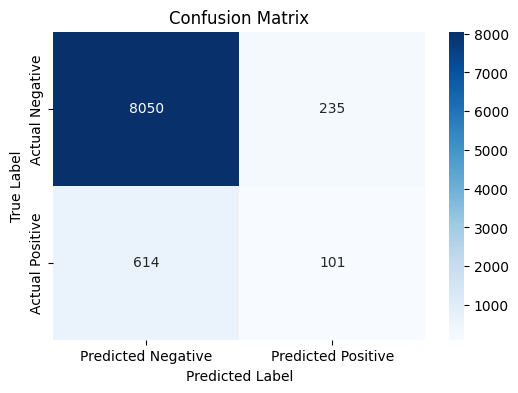

In [21]:
conf_mat= metrics.confusion_matrix(Y_test,Y_pred) # Confusion matrix
conf_mat

plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Negative", "Predicted Positive"], yticklabels=["Actual Negative", "Actual Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix1.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
from sklearn.model_selection import GridSearchCV

# Selecting the optimal n_estimators parameter
RF1=ensemble.RandomForestClassifier(n_estimators=50,criterion='entropy',max_features=None,random_state=1)
ntrees={'n_estimators': [50,100,150,180,220,250,300,320,350]} # Grid of n_estimators parameter length = 8

grid_search=GridSearchCV(estimator=RF1,param_grid=ntrees,scoring='precision',cv=5)

grid_search.fit(X_train,Y_train) # Fitting decision tree classifier to the training set
best_nestimator= grid_search.best_params_ # Selecting the optimal parameter n_estimators
print(best_nestimator)

{'n_estimators': 350}


In [23]:
# Refit the random forest on the optimal n_estimators parameter
RF2=ensemble.RandomForestClassifier(n_estimators=180,criterion='entropy',max_features=None,random_state=1)
RF2.fit(X_train,Y_train) # fitting random forest to training data
Y_pred=RF2.predict(X_test)

# fit model with n_Estimator
from sklearn import metrics
Accuracy= metrics.accuracy_score(Y_test,Y_pred)
Recall= metrics.recall_score(Y_test,Y_pred)
Precision= metrics.precision_score(Y_test,Y_pred)
print('Accuracy:', Accuracy)
print('Recall:', Recall)
print('Precision:', Precision)

Accuracy: 0.9034444444444445
Recall: 0.11888111888111888
Precision: 0.2623456790123457


#LINEAR REGRESSION

In [ ]:

# Compute the correlation matrix
cor = data2.corr()

# Create an annotated heatmap
f = ff.create_annotated_heatmap(
    z=cor.values,                          # Correlation values
    x=list(cor.columns),                   # X-axis labels (column names)
    y=list(cor.columns),                   # Y-axis labels (column names)
    annotation_text=cor.round(2).values,   # Rounded correlation values for annotation
    showscale=True                         # Show color scale
)

# Update layout to increase size
f.update_layout(
    width=1500,   # Adjust width (in pixels)
    height=1500   # Adjust height (in pixels)
)

# Show the figure
f.show()

In [ ]:
data1= data2.drop(['Checkup_Within the past 2 years','Checkup_Within the past year'],axis=1)
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 302051 to 91259
Data columns (total 40 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Exercise                                             30000 non-null  int64  
 1   Heart_Disease                                        30000 non-null  int64  
 2   Skin_Cancer                                          30000 non-null  int64  
 3   Other_Cancer                                         30000 non-null  int64  
 4   Depression                                           30000 non-null  int64  
 5   Arthritis                                            30000 non-null  int64  
 6   Sex                                                  30000 non-null  int64  
 7   Height_(cm)                                          30000 non-null  float64
 8   Weight_(kg)                                          30000 non-nul

In [ ]:
X = data1.drop(['BMI'],axis=1)
Y = data1['BMI']

In [ ]:
X_st=StandardScaler().fit_transform(X)

In [ ]:
LR=linear_model.SGDRegressor(random_state=1,penalty=None) # Linear regression without the regularisation
hyper_param={'eta0':[0.001,0.01,0.1,1],'max_iter':[1000,2000,3000,4000]}
grid_search=GridSearchCV(estimator=LR,param_grid=hyper_param,scoring='r2',cv=5) # R^2 tells how the good the linear model has fitted the dataset.
grid_search.fit(X_st,Y) # Fitting the linear model

GridSearchCV(cv=5, estimator=SGDRegressor(penalty=None, random_state=1),
             param_grid={'eta0': [0.001, 0.01, 0.1, 1],
                         'max_iter': [1000, 2000, 3000, 4000]},
             scoring='r2')

In [ ]:
# Optimal parameters
best_params= grid_search.best_params_
print(best_params)
best_result=grid_search.best_score_
print(best_result)
best_model=grid_search.best_estimator_
print('Beta_0:',best_model.intercept_)
#best_model.coef_
print(DataFrame(zip(X.columns,best_model.coef_),columns=['Columns/features','Beta coefficients']))

{'eta0': 0.001, 'max_iter': 1000}
0.9798453015940461
Beta_0: [28.57491475]
                                     Columns/features  Beta coefficients
0                                            Exercise          -0.028058
1                                       Heart_Disease           0.004033
2                                         Skin_Cancer          -0.002346
3                                        Other_Cancer           0.010264
4                                          Depression           0.017426
5                                           Arthritis           0.023229
6                                                 Sex           0.035441
7                                         Height_(cm)          -3.627286
8                                         Weight_(kg)           7.230082
9                                     Smoking_History          -0.007724
10                                Alcohol_Consumption           0.002901
11                                  Fruit_Consump

Mean Absolute Error (MAE): 0.5221253405167671
Mean Squared Error (MSE): 0.9676958869604878
Root Mean Squared Error (RMSE): 0.9837153485437176
R-squared (R²): 0.9773618751151507


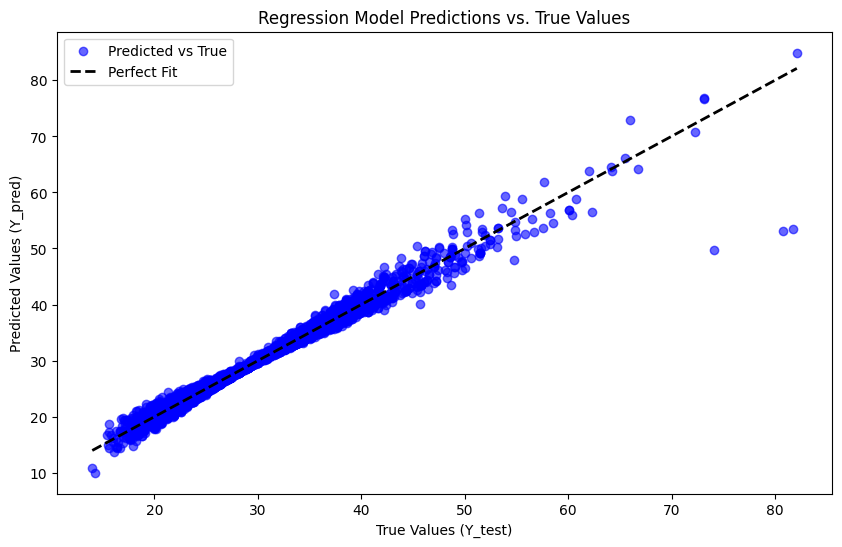

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X_st, Y, test_size=0.2, random_state=1)

# Train the best model on the training data
best_model.fit(X_train, Y_train)

# Predict on the test set
Y_pred = best_model.predict(X_test)

# Calculate and print regression evaluation metrics
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

# Optional: Compare predictions vs true values visually
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred, color='blue', alpha=0.6, label="Predicted vs True")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2, label="Perfect Fit")
plt.xlabel("True Values (Y_test)")
plt.ylabel("Predicted Values (Y_pred)")
plt.title("Regression Model Predictions vs. True Values")
plt.legend()
plt.show()
